In [1]:
import pandas as pd

In [2]:
with open('HomeDatasetTehran_R4_1404_02.txt','r', encoding='utf-8') as f:
    lines = f.readlines()
print(len(lines))
s = pd.Series(index=range(0, len(lines)), dtype=int)
c = 0
for i, line in enumerate(lines):
    s[i] = len(line.split('\t'))
s.value_counts()

980


32.0    945
33.0     23
34.0      7
31.0      4
28.0      1
Name: count, dtype: int64

In [3]:
len(lines[0].split('\t'))

28

In [4]:
from itertools import zip_longest

def print_lists_side_by_side(list1, list2):
    print(f"{'Index':<6} | {'List1':<15} | {'List2':<15}")
    print('-' * 35)
    for i, (val1, val2) in enumerate(zip_longest(list1, list2)):
        print(f"{i:<6} | {str(val1):<15} | {str(val2):<15}")

In [5]:
print_lists_side_by_side(lines[0].split('\t'), lines[64].split('\t'))

Index  | List1           | List2          
-----------------------------------
0      | h_type          | آپارتمان       
1      | date            | 1404/01/30     
2      | adress          | دلاوران خ تكاوران شمالی
3      | loc             | 4              
4      | num_floor       | 3              
5      | unit_per_floor  | 2              
6      | price           | 7,000,000,000 تومان
7      | age             | 200            
8      | statuse         | 22             
9      | view            | اجاره          
10     | doc_status      | سنگ            
11     | north           | 0              
12     | sought          | 1              
13     | west            | 0              
14     | east            | 0              
15     | floor           | 1              
16     | area            | 62             
17     | num_sleep       | 2              
18     | tel             | 1              
19     | kitch           | MDF            
20     | service         | ايراني فرنگي   
21    

In [6]:
lines[824].split('\t')[7]

'1000'

In [7]:
with open('HomeDatasetTehran_R4_1404_02.txt','r', encoding='utf-8') as f:
    lines = f.readlines()
line_item = []
for l in lines:
    new_line =  [item.strip() for item in l.split('\t')]
    c_item = len(new_line)
    match c_item:
        case 31:
            continue
        case 32:
            new_line = new_line[:28]
        case 33:
            new_line.pop(7)
            new_line = new_line[:28]
        case 34:
            continue
    line_item.append('\t'.join(new_line))
with open('HomeDatasetTehran0402.txt','w', encoding='utf-8') as f:
    for line in line_item:
        f.write(line + '\n')

In [8]:
df = pd.read_csv('HomeDatasetTehran0402.txt', sep='\t')
df.head(2)

,h_type,date,adress,loc,num_floor,unit_per_floor,price,age,statuse,view,...,tel,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment,nearby
0,آپارتمان,1404/01/28,تهرانپارس خ 188غربی,4,5,2,"14,000,000,000 تومان",15,مسکونی,سنگ,...,1,MDF,ايراني فرنگي,سنگ,1,1,1,1,شوفاژ_کولر_آسانسور_گاز,15
1,آپارتمان,1404/01/26,تهرانپارس بلوار پروین خ 196 شرقی,4,4,1,"4,500,000,000 تومان",1,تخلیه,سنگ,...,1,MDF,ايراني فرنگي,سراميک,1,0,1,1,پکیج,1


In [9]:
df.rename(columns={'adress': 'address'}, inplace=True)

In [10]:
df.head(2)

,h_type,date,address,loc,num_floor,unit_per_floor,price,age,statuse,view,...,tel,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment,nearby
0,آپارتمان,1404/01/28,تهرانپارس خ 188غربی,4,5,2,"14,000,000,000 تومان",15,مسکونی,سنگ,...,1,MDF,ايراني فرنگي,سنگ,1,1,1,1,شوفاژ_کولر_آسانسور_گاز,15
1,آپارتمان,1404/01/26,تهرانپارس بلوار پروین خ 196 شرقی,4,4,1,"4,500,000,000 تومان",1,تخلیه,سنگ,...,1,MDF,ايراني فرنگي,سراميک,1,0,1,1,پکیج,1


In [11]:
df.date.value_counts()

date
1404/01/30    105
1404/02/02     98
1404/02/03     94
1404/01/31     92
1404/02/01     92
1404/01/27     90
1404/01/26     84
1404/02/06     77
1404/01/25     76
1404/01/24     72
1404/01/28     47
1404/01/23     41
Name: count, dtype: int64

In [12]:
df.columns

Index(['h_type', 'date', 'address', 'loc', 'num_floor', 'unit_per_floor',
       'price', 'age', 'statuse', 'view', 'doc_status', 'north', 'sought',
       'west', 'east', 'floor', 'area', 'num_sleep', 'tel', 'kitch', 'service',
       'floor_covering', 'open', 'parking', 'warehouse', 'balcony',
       'equipment', 'nearby'],
      dtype='object')

In [13]:
df.shape

(968, 28)

In [14]:
df.h_type.value_counts()

h_type
آپارتمان    968
Name: count, dtype: int64

In [15]:
df = df.drop(['h_type','date','loc'], axis = 'columns')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 968 entries, 0 to 967
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   address         968 non-null    object 
 1   num_floor       968 non-null    int64  
 2   unit_per_floor  968 non-null    object 
 3   price           968 non-null    object 
 4   age             968 non-null    object 
 5   statuse         968 non-null    object 
 6   view            968 non-null    object 
 7   doc_status      968 non-null    object 
 8   north           968 non-null    int64  
 9   sought          968 non-null    int64  
 10  west            968 non-null    int64  
 11  east            968 non-null    object 
 12  floor           968 non-null    object 
 13  area            968 non-null    int64  
 14  num_sleep       967 non-null    float64
 15  tel             960 non-null    object 
 16  kitch           968 non-null    object 
 17  service         968 non-null    obj

In [17]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment', 'nearby'],
      dtype='object')

In [18]:
df['address'].nunique()   

621

In [19]:
# Define a function to convert each element in the 'price' column
def convert_price(price_str):
    return int(price_str.replace(',', '').replace(' تومان', ''))

# Apply the conversion function to the 'price' column
df['price'] = df['price'].apply(convert_price)

In [20]:
df['price'] = df['price'] / df['area']
df['price']

0      1.196581e+08
1      5.000000e+07
2      1.312500e+08
3      1.607143e+08
4      6.756757e+07
           ...     
963    1.150000e+08
964    8.510638e+07
965    6.666667e+07
966    6.500000e+07
967    6.666667e+07
Name: price, Length: 968, dtype: float64

In [21]:
df['price'].describe()

count    9.680000e+02
mean     2.289301e+08
std      8.647371e+08
min      2.785714e+07
25%      7.727002e+07
50%      9.654107e+07
75%      1.229272e+08
max      9.250000e+09
Name: price, dtype: float64

In [22]:
desc = df['price'].describe().apply(lambda x: float(x))  # Ensure numeric types
print(desc.apply(lambda x: f"{x:,.2f}"))  # Format with commas and 2 decimals

count              968.00
mean       228,930,065.82
std        864,737,061.04
min         27,857,142.86
25%         77,270,021.65
50%         96,541,068.58
75%        122,927,180.97
max      9,250,000,000.00
Name: price, dtype: object


In [23]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment', 'nearby'],
      dtype='object')

In [24]:
main_addres = ['استخر','پروین','خواجه عبدالله','شمیران نو','بنی هاشم','نیروی دریایی','میدان شاهد',
'فرجام','مجیدیه','تهران پارس','جشنواره','هروی','حكیمیه','شمس اباد','اتوبان بابایی','شمس آباد',
'دلاوران','دماوند','سراج','رسالت','لویزان',
'تهرانپارس','شهیدعراقی','شهید عراقی', 'شمس آّباد','هنگام','تهارنپارس',
'قنات كوثر','نیروی دریائی','ایت','خواجه عبداله','شریعتی']

def replace_address(s):
    for each_address in main_addres:
        if each_address in s:
            s = each_address
    return s

df['address'] = df['address'].apply(replace_address)
df['address'].unique()

array(['تهرانپارس', 'پروین', 'فرجام', 'هروی', 'هنگام', 'جشنواره', 'استخر',
       'حكیمیه', 'بنی هاشم', 'شمس آباد', 'مجیدیه', 'شمس اباد',
       'اتوبان بابایی', 'تهران پارس', 'رسالت', 'شمیران نو', 'شهیدعراقی',
       'قنات كوثر', 'دلاوران', 'لویزان', 'سراج', 'خواجه عبد الله خ چگینی',
       'خواجه عبدالله', 'نیروی دریایی', 'اتوبان باقری نرسیده به ریحانچی',
       'شریعتی', 'خواجه عبداله', 'شهید عراقی', 'نیروی دریائی'],
      dtype=object)

In [25]:
correct_address = {address:address for address in df['address']}
correct_address

{'تهرانپارس': 'تهرانپارس',
 'پروین': 'پروین',
 'فرجام': 'فرجام',
 'هروی': 'هروی',
 'هنگام': 'هنگام',
 'جشنواره': 'جشنواره',
 'استخر': 'استخر',
 'حكیمیه': 'حكیمیه',
 'بنی هاشم': 'بنی هاشم',
 'شمس آباد': 'شمس آباد',
 'مجیدیه': 'مجیدیه',
 'شمس اباد': 'شمس اباد',
 'اتوبان بابایی': 'اتوبان بابایی',
 'تهران پارس': 'تهران پارس',
 'رسالت': 'رسالت',
 'شمیران نو': 'شمیران نو',
 'شهیدعراقی': 'شهیدعراقی',
 'قنات كوثر': 'قنات كوثر',
 'دلاوران': 'دلاوران',
 'لویزان': 'لویزان',
 'سراج': 'سراج',
 'خواجه عبد الله خ چگینی': 'خواجه عبد الله خ چگینی',
 'خواجه عبدالله': 'خواجه عبدالله',
 'نیروی دریایی': 'نیروی دریایی',
 'اتوبان باقری نرسیده به ریحانچی': 'اتوبان باقری نرسیده به ریحانچی',
 'شریعتی': 'شریعتی',
 'خواجه عبداله': 'خواجه عبداله',
 'شهید عراقی': 'شهید عراقی',
 'نیروی دریائی': 'نیروی دریائی'}

In [26]:
correct_address['تهارنپارس'] = 'تهرانپارس'
correct_address['شمس آباد'] = 'شمس آّباد'
correct_address['شمس آّباد'] = 'شمس آّباد'
correct_address['شمس اباد'] = 'شمس آّباد'
correct_address['خواجه عبداله'] = 'خواجه عبدالله'
correct_address['نیروی دریائی'] = 'نیروی دریایی'
correct_address['تهران پارس'] = 'تهرانپارس'
correct_address['بزرگراه بابایی شهرك كوثر'] = 'اتوبان بابایی'

df['address'] = df['address'].map(correct_address)
df['address'].unique()

array(['تهرانپارس', 'پروین', 'فرجام', 'هروی', 'هنگام', 'جشنواره', 'استخر',
       'حكیمیه', 'بنی هاشم', 'شمس آّباد', 'مجیدیه', 'اتوبان بابایی',
       'رسالت', 'شمیران نو', 'شهیدعراقی', 'قنات كوثر', 'دلاوران',
       'لویزان', 'سراج', 'خواجه عبد الله خ چگینی', 'خواجه عبدالله',
       'نیروی دریایی', 'اتوبان باقری نرسیده به ریحانچی', 'شریعتی',
       'شهید عراقی'], dtype=object)

In [27]:
correct_address

{'تهرانپارس': 'تهرانپارس',
 'پروین': 'پروین',
 'فرجام': 'فرجام',
 'هروی': 'هروی',
 'هنگام': 'هنگام',
 'جشنواره': 'جشنواره',
 'استخر': 'استخر',
 'حكیمیه': 'حكیمیه',
 'بنی هاشم': 'بنی هاشم',
 'شمس آباد': 'شمس آّباد',
 'مجیدیه': 'مجیدیه',
 'شمس اباد': 'شمس آّباد',
 'اتوبان بابایی': 'اتوبان بابایی',
 'تهران پارس': 'تهرانپارس',
 'رسالت': 'رسالت',
 'شمیران نو': 'شمیران نو',
 'شهیدعراقی': 'شهیدعراقی',
 'قنات كوثر': 'قنات كوثر',
 'دلاوران': 'دلاوران',
 'لویزان': 'لویزان',
 'سراج': 'سراج',
 'خواجه عبد الله خ چگینی': 'خواجه عبد الله خ چگینی',
 'خواجه عبدالله': 'خواجه عبدالله',
 'نیروی دریایی': 'نیروی دریایی',
 'اتوبان باقری نرسیده به ریحانچی': 'اتوبان باقری نرسیده به ریحانچی',
 'شریعتی': 'شریعتی',
 'خواجه عبداله': 'خواجه عبدالله',
 'شهید عراقی': 'شهید عراقی',
 'نیروی دریائی': 'نیروی دریایی',
 'تهارنپارس': 'تهرانپارس',
 'شمس آّباد': 'شمس آّباد',
 'بزرگراه بابایی شهرك كوثر': 'اتوبان بابایی'}

In [28]:
df.head(2)

,address,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,...,tel,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment,nearby
0,تهرانپارس,5,2,1.196581e+08,15,مسکونی,سنگ,شخصي,0,1,...,1,MDF,ايراني فرنگي,سنگ,1,1,1,1,شوفاژ_کولر_آسانسور_گاز,15
1,پروین,4,1,5.000000e+07,1,تخلیه,سنگ,قولنامه اي,1,0,...,1,MDF,ايراني فرنگي,سراميک,1,0,1,1,پکیج,1


In [29]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment', 'nearby'],
      dtype='object')

In [30]:
df.floor.unique()
replace_floor = {floor:floor for floor in df.floor}
replace_floor

{'3': '3',
 '1': '1',
 '5': '5',
 '4': '4',
 '2': '2',
 '7': '7',
 '10': '10',
 'همكف': 'همكف',
 'زیرهمكف': 'زیرهمكف',
 '8': '8',
 '6': '6',
 '62': '62',
 '110': '110',
 '115': '115',
 '130': '130',
 '9': '9',
 '11': '11',
 '136': '136',
 '95': '95',
 'مختلف': 'مختلف',
 '128': '128',
 '15': '15',
 '106': '106',
 '150': '150',
 '105': '105',
 '92': '92',
 'دو واحد': 'دو واحد',
 '66': '66',
 '16': '16',
 '52': '52',
 '510': '510',
 '85': '85',
 '80': '80',
 '73': '73',
 '116': '116',
 'سه واحد': 'سه واحد',
 '156': '156',
 '90': '90'}

In [31]:
replace_floor ={'3': '3',
 '1': '1',
 '5': '5',
 '4': '4',
 '2': '2',
 '7': '7',
 '10': '10',
 'همكف': '0',
 'زیرهمكف': '-1',
 '8': '8',
 '6': '6',
 '62': '62',
 '110': '110',
 '115': '115',
 '130': '130',
 '9': '9',
 '11': '11',
 '136': '136',
 '95': '95',
 'مختلف': '2',
 '128': '128',
 '15': '15',
 '106': '106',
 '150': '150',
 '105': '105',
 '92': '92',
 'دو واحد': '-2',
 '66': '66',
 '16': '16',
 '52': '52',
 '510': '510',
 '85': '85',
 '80': '80',
 '73': '73',
 '116': '116',
 'سه واحد': '-3',
 '156': '156',
 '90': '90'}

df['floor'] = df['floor'].map(replace_floor)
df['floor'] = df['floor'].astype(int)
df.floor.unique()

array([  3,   1,   5,   4,   2,   7,  10,   0,  -1,   8,   6,  62, 110,
       115, 130,   9,  11, 136,  95, 128,  15, 106, 150, 105,  92,  -2,
        66,  16,  52, 510,  85,  80,  73, 116,  -3, 156,  90])

In [32]:
df.floor.value_counts()

floor
 1      216
 4      213
 3      196
 2      163
 5       62
 0       39
-1       14
 6       12
 7        7
 10       6
 11       5
 9        4
 8        2
 128      2
 110      2
-2        2
 150      2
 16       2
 115      1
 62       1
 130      1
 15       1
 95       1
 136      1
 106      1
 92       1
 105      1
 66       1
 52       1
 510      1
 85       1
 80       1
 73       1
 116      1
-3        1
 156      1
 90       1
Name: count, dtype: int64

df.age.value_counts()

In [33]:
df.age.value_counts()

age
نوساز    135
20        83
30        63
18        51
16        39
22        38
17        37
1         34
15        34
23        32
10        31
12        31
13        27
19        26
2         26
7         26
8         25
3         24
6         23
5         23
9         22
25        21
21        21
24        20
11        19
14        18
4         17
27         9
28         6
26         5
29         2
Name: count, dtype: int64

In [34]:
df.age=df.age.str.replace('نوساز','0')

In [35]:
df.age = df.age.astype(int)

In [36]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment', 'nearby'],
      dtype='object')

In [37]:
dict(df['kitch'].value_counts())

{'MDF': np.int64(818),
 'هایگلاس': np.int64(64),
 'چوبي': np.int64(23),
 'ايراني فرنگي': np.int64(16),
 'فلزي': np.int64(14),
 'نا مشخص': np.int64(14),
 'دلخواه': np.int64(7),
 'ايرانی': np.int64(6),
 'ندارد': np.int64(3),
 'چوبي فلزي': np.int64(1),
 'آبدارخانه': np.int64(1),
 'فرنگی': np.int64(1)}

In [38]:
kitch_map = {'MDF': 50,
 'هایگلاس': 60,
 'چوبي': 70,
 'ايراني فرنگي': 40,
 'فلزي': 5,
 'نا مشخص': 0,
 'دلخواه': 0,
 'ايرانی': 5,
 'ندارد': 0,
 'چوبي فلزي': 10,
 'آبدارخانه': 1,
 'فرنگی': 6}
df['kitch'] = df['kitch'].map(kitch_map)

In [39]:
dict(df['service'].value_counts())

{'ايراني فرنگي': np.int64(602),
 'ايرانی': np.int64(319),
 'فرنگی': np.int64(21),
 'سراميک': np.int64(16),
 'نامشخص': np.int64(3),
 'سنگ': np.int64(3),
 'پارکت': np.int64(2),
 'موکت': np.int64(1),
 'لامنيت': np.int64(1)}

In [40]:
service_map ={'ايراني فرنگي': 15,
 'ايرانی': 5,
 'فرنگی': 10,
 'سراميک': 5,
 'نامشخص': 5,
 'سنگ': 5,
 'پارکت': 5,
 'موکت':5,
 'لامنيت': 5}
df['service'] = df['service'].map(service_map)

In [41]:
dict(df['floor_covering'].value_counts())

{'سراميک': np.int64(617),
 'سنگ': np.int64(219),
 'پارکت': np.int64(75),
 '1': np.int64(21),
 'لامنيت': np.int64(15),
 'موکت': np.int64(9),
 'موزائيک': np.int64(4),
 '0': np.int64(2),
 'نا مشخص': np.int64(2),
 'سراميک موزائيک': np.int64(1),
 'سنگ سراميک': np.int64(1),
 'کفپوش': np.int64(1),
 'PVC': np.int64(1)}

In [42]:
floor_covering = {'سراميک': 10,
 'سنگ': 8,
 'پارکت': 15,
 '1': 10,
 'لامنيت': 20,
 'موکت': 5,
 'موزائيک': 7,
 '0': 0,
 'نا مشخص': 0,
 'سراميک موزائيک': 9,
 'سنگ سراميک': 9,
 'کفپوش': 8,
 'PVC': 10}
df['floor_covering'] = df['floor_covering'].map(floor_covering)

In [43]:
df['open'].value_counts()

open
1    913
0     55
Name: count, dtype: int64

In [44]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment', 'nearby'],
      dtype='object')

In [45]:
dict(df.equipment.value_counts())

{'شوفاژ_کولر_آسانسور_گاز': np.int64(184),
 'کولر_گاز': np.int64(148),
 'شوفاژ_کولر_گاز': np.int64(148),
 'شوفاژ_کولر_آسانسور_پکیج_گاز': np.int64(108),
 'کولر_آسانسور_پکیج_گاز': np.int64(79),
 'کولر_آسانسور_پکیج': np.int64(56),
 'شوفاژ_کولر_آسانسور': np.int64(41),
 'کولر_آسانسور_گاز': np.int64(35),
 'شوفاژ_کولر': np.int64(31),
 'شوفاژ_کولر_پکیج_گاز': np.int64(28),
 'کولر_پکیج_گاز': np.int64(14),
 'کولر_پکیج': np.int64(10),
 'آسانسور_پکیج': np.int64(6),
 'پکیج': np.int64(4),
 'آسانسور': np.int64(4),
 'آسانسور_چیلر': np.int64(4),
 'شوفاژ_کولر_آسانسور_حیاط_گاز': np.int64(3),
 '200': np.int64(3),
 'آسانسور_چیلر_گاز': np.int64(3),
 'کولر_آسانسور_پاسیو_پکیج_گاز': np.int64(2),
 'شوفاژ_کولر_آسانسور_حیاط': np.int64(2),
 'شوفاژ_آسانسور_پکیج': np.int64(2),
 '250': np.int64(2),
 '225': np.int64(2),
 'آسانسور_گاز': np.int64(2),
 'کولر_پاسیو_گاز': np.int64(2),
 '780': np.int64(1),
 'شوفاژ_کولر_آسانسور_سونا_گاز': np.int64(1),
 '30': np.int64(1),
 '191': np.int64(1),
 'شوفاژ_کولر_حیاط_زیر زمین_مستخدم_پ

In [46]:
for item in df.equipment:
    if isinstance(item, float) or item.isdigit():
        print(item)

200
1200
216
nan
780
400
nan
191
30
225
225
nan
184
250
180
92
200
200
264
1050
4000
1000
446
280
250
420


In [47]:
mask = df['equipment'].apply(lambda x: isinstance(x, (int, float)) or (isinstance(x, str) and x.replace('.', '', 1).isdigit()))

for item in df.loc[mask, 'equipment']:
    print(item)

df = df[~mask].reset_index(drop=True)

200
1200
216
nan
780
400
nan
191
30
225
225
nan
184
250
180
92
200
200
264
1050
4000
1000
446
280
250
420


In [48]:
df.shape

(942, 25)

In [49]:
equipment = []
for item in df.equipment:
    if not isinstance(item, str):
        continue
    item = item.split('_')
    if item not in equipment:
        equipment.append(item)
s = set()
for i in equipment:
    s = s.union(set(i))
{k:0 for k in s}

{'زیر زمین': 0,
 'استخر': 0,
 'آسانسور': 0,
 'مستخدم': 0,
 'گاز': 0,
 'سونا': 0,
 'حیاط': 0,
 'فن کوئر': 0,
 'چیلر': 0,
 'حیاط خلوت': 0,
 'کولر': 0,
 'پکیج': 0,
 'پاسیو': 0,
 'جکوزی': 0,
 'شوفاژ': 0}

In [50]:
equipment_value = {'حیاط': 10,
 'جکوزی': 20,
 'سونا': 20,
 'پکیج': 5,
 'کولر': 2,
 'زیر زمین': 15,
 'مستخدم': 1,
 'آسانسور': 10,
 'پاسیو': 8,
 'چیلر': 3,
 'شوفاژ': 3,
 'گاز': 1,
 'فن کوئر': 1,
 'استخر': 20,
 'حیاط خلوت': 15}

def get_equip_value(equip):
    eqs = equip.split('_')
    value = 0
    for eq in eqs:
        value += equipment_value[eq]
    return value
df['equipment'] = df['equipment'].apply(get_equip_value)

In [51]:
df['equipment'].describe()

count    942.000000
mean      12.444798
std        7.018166
min        1.000000
25%        6.000000
50%       15.000000
75%       17.000000
max       76.000000
Name: equipment, dtype: float64

In [52]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment', 'nearby'],
      dtype='object')

In [53]:
dict(df.statuse.value_counts())

{'مسکونی': np.int64(442), 'تخلیه': np.int64(342), 'اجاره': np.int64(158)}

In [54]:
status_value = {'مسکونی':6, 
                'تخلیه': 8, 
                'اجاره': 6}
df['statuse'] = df['statuse'].map(status_value)

In [55]:
dict(df.view.value_counts())

{'سنگ': np.int64(826),
 'ترکیبی': np.int64(23),
 'سيمان': np.int64(21),
 'آجر': np.int64(19),
 'گرانيت': np.int64(16),
 'آجر سه سانت': np.int64(16),
 'تراورتن': np.int64(13),
 'کنيتکس': np.int64(2),
 'رومي': np.int64(2),
 'شيشه': np.int64(1),
 'کامپوزيت': np.int64(1),
 'سنگ و رومي': np.int64(1),
 'کلاسيک': np.int64(1)}

In [56]:
view_value = {
    'سنگ': 22,
 'ترکیبی': 21,
 'سيمان': 10,
 'آجر': 10,
 'گرانيت': 27,
 'آجر سه سانت': 18,
 'تراورتن': 25,
 'کنيتکس': 24,
 'رومي': 30,
 'شيشه': 28,
 'کامپوزيت': 29,
 'سنگ و رومي': 30,
 'کلاسيک': 20}
df['view'] = df['view'].map(view_value)

In [57]:
dict(df['doc_status'].value_counts())

{'شخصي': np.int64(791),
 'قولنامه اي': np.int64(77),
 'تعاوني': np.int64(34),
 'دردست اقدام': np.int64(15),
 'مسکوني': np.int64(12),
 'منگوله دار': np.int64(7),
 'مشاع': np.int64(3),
 'اوقافي': np.int64(2),
 'آماده محضر': np.int64(1)}

In [58]:
doc_status_value = {'شخصي': 10,
 'قولنامه اي': 3,
 'تعاوني': 7,
 'دردست اقدام':7,
 'مسکوني': 10,
 'منگوله دار': 10,
 'مشاع': 6,
 'اوقافي': 6,
 'آماده محضر': 10}
df['doc_status'] = df['doc_status'].map(doc_status_value)

In [59]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment', 'nearby'],
      dtype='object')

In [60]:
dict(df['nearby'].value_counts())

{'نوساز': np.int64(135),
 '20': np.int64(81),
 '30': np.int64(55),
 '18': np.int64(49),
 '16': np.int64(38),
 '17': np.int64(35),
 '22': np.int64(35),
 '1': np.int64(34),
 '15': np.int64(33),
 '23': np.int64(32),
 '12': np.int64(31),
 '10': np.int64(30),
 '13': np.int64(27),
 '19': np.int64(26),
 '2': np.int64(26),
 '7': np.int64(26),
 '8': np.int64(24),
 '6': np.int64(23),
 '3': np.int64(23),
 '5': np.int64(23),
 '9': np.int64(22),
 '21': np.int64(21),
 '25': np.int64(20),
 '24': np.int64(19),
 '11': np.int64(19),
 '14': np.int64(17),
 '4': np.int64(17),
 '27': np.int64(8),
 '28': np.int64(6),
 '26': np.int64(5),
 '29': np.int64(2)}

In [61]:
df.drop(['nearby'], axis = 'columns', inplace=True)
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment'],
      dtype='object')

In [62]:
len(df.columns)

24

In [63]:
df.describe().shape[1]

19

In [64]:
str_columns = list(set(df.columns) - set(df.describe().columns))
str_columns

['address', 'balcony', 'unit_per_floor', 'tel', 'east']

In [65]:
dict(df['tel'].value_counts())

{'1': np.int64(869),
 '0': np.int64(41),
 '2': np.int64(22),
 '3': np.int64(1),
 'ابری': np.int64(1)}

In [66]:
df = df[df['tel'] != 'ابری']

In [67]:
dict(df['unit_per_floor'].value_counts())

{'2': np.int64(383),
 '1': np.int64(258),
 '4': np.int64(129),
 '3': np.int64(109),
 '6': np.int64(13),
 '5': np.int64(10),
 '9': np.int64(9),
 '8': np.int64(8),
 '7': np.int64(8),
 '10': np.int64(6),
 '12': np.int64(4),
 '20': np.int64(2),
 '---': np.int64(1),
 '11': np.int64(1)}

In [68]:
df = df[df['unit_per_floor'] != '---']

In [69]:
for col in str_columns:
    if col == 'address':
        continue
    df[col] = df[col].astype('float')

In [70]:
(len(df.columns) -1)  == (df.describe().shape[1])

True

In [71]:
len(df.columns) - 1

23

In [72]:
df.describe().shape[1]

23

In [73]:
str_columns = list(set(df.columns) - set(df.describe().columns))
str_columns

['address']

In [74]:
df.describe()

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,...,num_sleep,tel,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment
count,940.000000,940.000000,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,...,940.000000,932.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.847872,2.505319,1.017704e+08,13.075532,6.727660,21.564894,9.248936,0.502128,0.522340,0.021277,...,1.894681,0.981760,49.128723,11.478723,10.003191,0.948936,0.629787,0.889362,0.602128,12.445745
std,2.157594,1.898089,4.121518e+07,9.172564,0.962713,2.664611,2.002062,0.500262,0.499767,0.144382,...,0.659633,0.267643,10.686621,4.722837,2.234636,0.220245,0.483119,0.313851,0.489719,7.023180
min,2.000000,1.000000,2.785714e+07,0.000000,6.000000,10.000000,3.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4.000000,1.000000,7.632035e+07,4.750000,6.000000,22.000000,10.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,50.000000,5.000000,9.000000,1.000000,0.000000,1.000000,0.000000,6.000000
50%,4.000000,2.000000,9.536704e+07,14.000000,6.000000,22.000000,10.000000,1.000000,1.000000,0.000000,...,2.000000,1.000000,50.000000,15.000000,10.000000,1.000000,1.000000,1.000000,1.000000,15.000000
75%,5.000000,3.000000,1.200000e+08,20.000000,8.000000,22.000000,10.000000,1.000000,1.000000,0.000000,...,2.000000,1.000000,50.000000,15.000000,10.000000,1.000000,1.000000,1.000000,1.000000,17.000000
max,24.000000,20.000000,6.363636e+08,30.000000,8.000000,30.000000,10.000000,1.000000,1.000000,1.000000,...,6.000000,3.000000,70.000000,15.000000,20.000000,1.000000,1.000000,1.000000,1.000000,76.000000


In [75]:
dict(df['address'].value_counts())

{'تهرانپارس': np.int64(201),
 'جشنواره': np.int64(95),
 'پروین': np.int64(94),
 'فرجام': np.int64(68),
 'شمس آّباد': np.int64(68),
 'هروی': np.int64(56),
 'شمیران نو': np.int64(38),
 'استخر': np.int64(37),
 'حكیمیه': np.int64(36),
 'بنی هاشم': np.int64(33),
 'اتوبان بابایی': np.int64(28),
 'سراج': np.int64(27),
 'لویزان': np.int64(25),
 'خواجه عبدالله': np.int64(22),
 'مجیدیه': np.int64(21),
 'قنات كوثر': np.int64(20),
 'رسالت': np.int64(17),
 'هنگام': np.int64(16),
 'دلاوران': np.int64(11),
 'شهیدعراقی': np.int64(10),
 'نیروی دریایی': np.int64(8),
 'شهید عراقی': np.int64(5),
 'شریعتی': np.int64(2),
 'خواجه عبد الله خ چگینی': np.int64(1),
 'اتوبان باقری نرسیده به ریحانچی': np.int64(1)}

In [76]:
{K:K for K in df['address'].unique()}

{'تهرانپارس': 'تهرانپارس',
 'پروین': 'پروین',
 'فرجام': 'فرجام',
 'هروی': 'هروی',
 'هنگام': 'هنگام',
 'جشنواره': 'جشنواره',
 'استخر': 'استخر',
 'حكیمیه': 'حكیمیه',
 'بنی هاشم': 'بنی هاشم',
 'شمس آّباد': 'شمس آّباد',
 'مجیدیه': 'مجیدیه',
 'اتوبان بابایی': 'اتوبان بابایی',
 'رسالت': 'رسالت',
 'شمیران نو': 'شمیران نو',
 'شهیدعراقی': 'شهیدعراقی',
 'قنات كوثر': 'قنات كوثر',
 'لویزان': 'لویزان',
 'سراج': 'سراج',
 'خواجه عبد الله خ چگینی': 'خواجه عبد الله خ چگینی',
 'خواجه عبدالله': 'خواجه عبدالله',
 'نیروی دریایی': 'نیروی دریایی',
 'اتوبان باقری نرسیده به ریحانچی': 'اتوبان باقری نرسیده به ریحانچی',
 'شریعتی': 'شریعتی',
 'دلاوران': 'دلاوران',
 'شهید عراقی': 'شهید عراقی'}

In [77]:
address_value = {'تهرانپارس': 'تهرانپارس',
 'پروین': 'پروین',
 'فرجام': 'فرجام',
 'هروی': 'هروی',
 'هنگام': 'هنگام',
 'جشنواره': 'جشنواره',
 'استخر': 'استخر',
 'حكیمیه': 'حكیمیه',
 'بنی هاشم': 'بنی هاشم',
 'شمس آّباد': 'شمس آّباد',
 'مجیدیه': 'مجیدیه',
 'اتوبان بابایی': 'بابایی',
 'رسالت': 'رسالت',
 'شمیران نو': 'شمیران نو',
 'شهیدعراقی': 'عراقی',
 'قنات كوثر': 'قنات كوثر',
 'لویزان': 'لویزان',
 'سراج': 'سراج',
 'خواجه عبد الله خ چگینی': 'خواجه عبدالله',
 'خواجه عبدالله': 'خواجه عبدالله',
 'نیروی دریایی': 'نیروی دریایی',
 'اتوبان باقری نرسیده به ریحانچی': 'باقری',
 'شریعتی': 'شریعتی',
 'دلاوران': 'دلاوران',
 'شهید عراقی': 'عراقی'}
df['address'] = df['address'].map(address_value)
df['address'].value_counts()

address
تهرانپارس        201
جشنواره           95
پروین             94
فرجام             68
شمس آّباد         68
هروی              56
شمیران نو         38
استخر             37
حكیمیه            36
بنی هاشم          33
بابایی            28
سراج              27
لویزان            25
خواجه عبدالله     23
مجیدیه            21
قنات كوثر         20
رسالت             17
هنگام             16
عراقی             15
دلاوران           11
نیروی دریایی       8
شریعتی             2
باقری              1
Name: count, dtype: int64

In [78]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment'],
      dtype='object')

<Axes: >

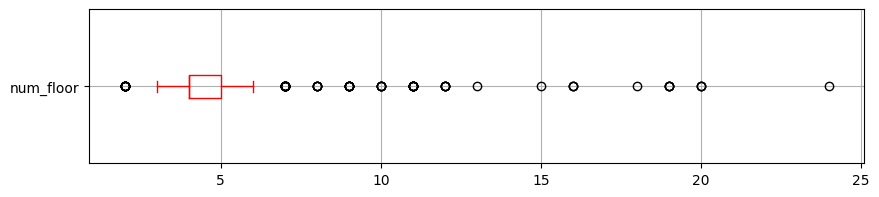

In [79]:
df.num_floor.plot.box(vert=False, figsize=(10, 2), color='red', grid=True)

<Axes: xlabel='num_floor'>

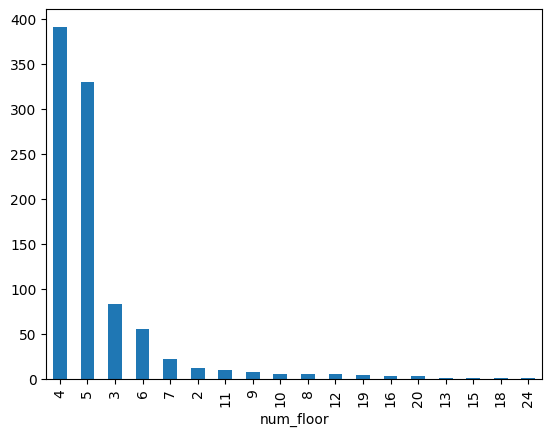

In [80]:
df.num_floor.value_counts().plot.bar()

<Axes: >

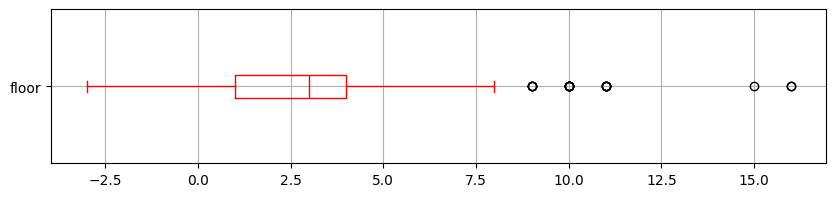

In [81]:
df.floor.plot.box(vert=False, figsize=(10, 2), color='red', grid=True)

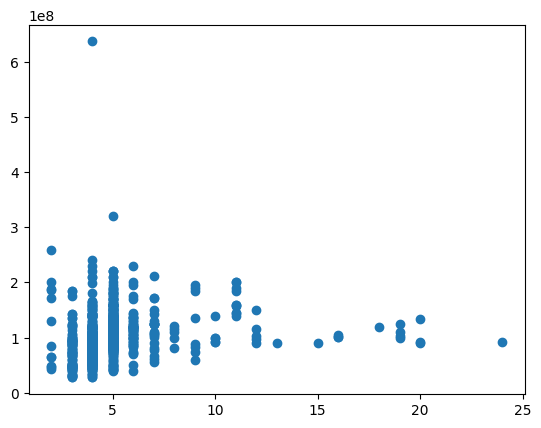

In [82]:
import matplotlib.pyplot as plt
plt.scatter(df['num_floor'], df['price'])

<Axes: >

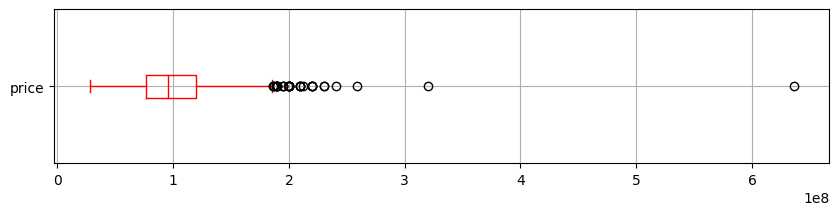

In [83]:
df['price'].plot.box(vert=False, figsize=(10, 2), color='red', grid=True)   

In [84]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].shape

(908, 24)

In [85]:
q1

np.float64(76320346.32034633)

In [86]:
q3

np.float64(120000000.0)

In [87]:
desc = df['price'].describe().apply(lambda x: float(x))  # Ensure numeric types
print(desc.apply(lambda x: f"{x:,.2f}"))  # Format with commas and 2 decimals

count            940.00
mean     101,770,396.14
std       41,215,180.16
min       27,857,142.86
25%       76,320,346.32
50%       95,367,041.56
75%      120,000,000.00
max      636,363,636.36
Name: price, dtype: object


<Axes: >

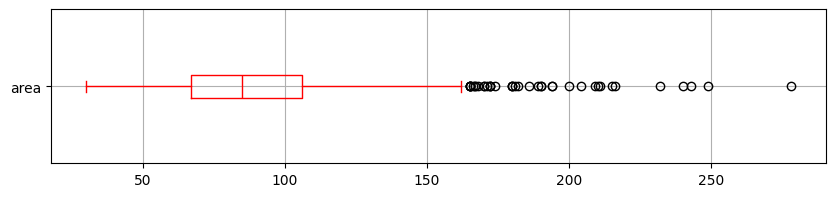

In [88]:
df['area'].plot.box(vert=False, figsize=(10, 2), color='red', grid=True) 

In [89]:
q1 = df['area'].quantile(0.25)
q3 = df['area'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df[(df['area'] >= lower_bound) & (df['area'] <= upper_bound)].shape

(901, 24)

In [90]:
desc = df['area'].describe().apply(lambda x: float(x))  # Ensure numeric types
print(desc.apply(lambda x: f"{x:,.2f}"))  # Format with commas and 2 decimals

count    940.00
mean      90.75
std       33.83
min       30.00
25%       67.00
50%       85.00
75%      106.00
max      278.00
Name: area, dtype: object


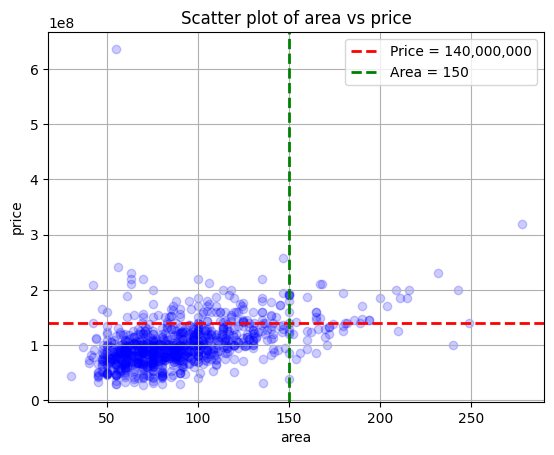

np.float64(0.46921191867474715)

In [91]:
plt.scatter(df['area'], df['price'], alpha=0.2, color='blue')
plt.xlabel('area')
plt.ylabel('price')
plt.title('Scatter plot of area vs price')
plt.axhline(y=140000000, color='r', linestyle='--', linewidth=2, label='Price = 140,000,000')
plt.axvline(x=150, color='g', linestyle='--', linewidth=2, label='Area = 150')
plt.grid(True)
plt.legend()
plt.show()
df['price'].corr(df['area'])


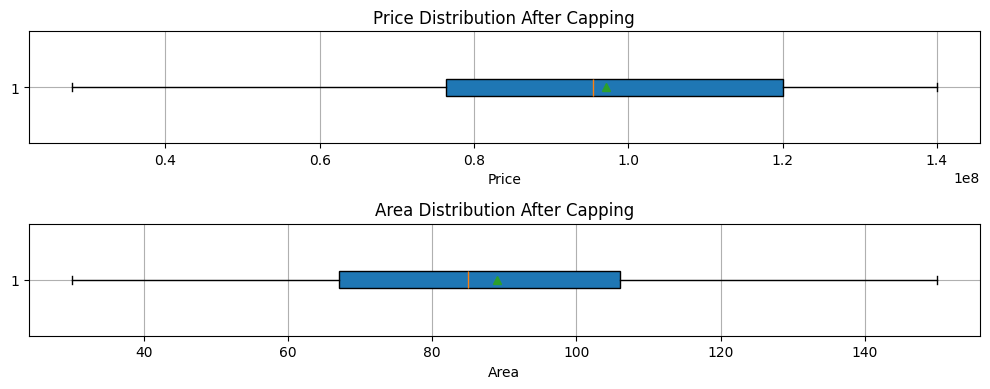

In [92]:
upper_bound_price = 140000000
upper_bound_area = 150
df.loc[df['price'] > upper_bound_price, 'price'] = upper_bound_price
df.loc[df['area'] > upper_bound_area, 'area'] = upper_bound_area

plt.figure(figsize=(10, 4))

plt.subplot(2, 1, 1)
plt.title('Price Distribution After Capping')
plt.boxplot(df['price'], vert=False, patch_artist=True, showmeans=True)
plt.xlabel('Price')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.title('Area Distribution After Capping')
plt.boxplot(df['area'], vert=False, patch_artist=True, showmeans=True)
plt.xlabel('Area')
plt.grid(True)

plt.tight_layout()
plt.show()

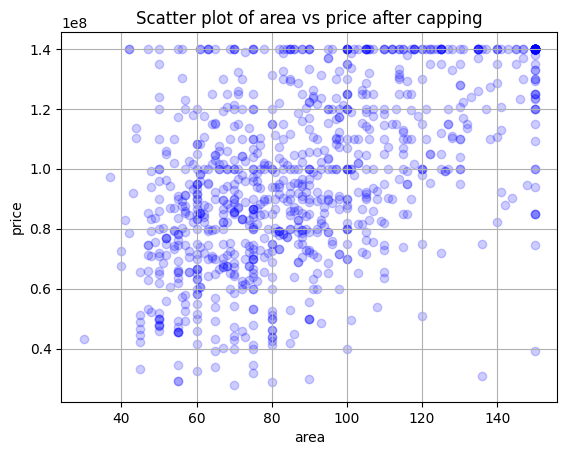

np.float64(0.527003888883016)

In [93]:
plt.scatter(df['area'], df['price'], alpha=0.2, color='blue')
plt.xlabel('area')
plt.ylabel('price')
plt.title('Scatter plot of area vs price after capping')
plt.grid(True)
plt.show()
df['price'].corr(df['area'])

In [94]:
df.columns

Index(['address', 'num_floor', 'unit_per_floor', 'price', 'age', 'statuse',
       'view', 'doc_status', 'north', 'sought', 'west', 'east', 'floor',
       'area', 'num_sleep', 'tel', 'kitch', 'service', 'floor_covering',
       'open', 'parking', 'warehouse', 'balcony', 'equipment'],
      dtype='object')

<Axes: >

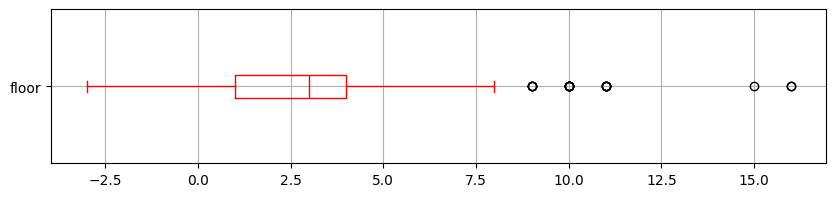

In [95]:
df.floor.plot.box(vert=False, figsize=(10, 2), color='red', grid=True)

In [96]:
df.floor.value_counts()

floor
 1     215
 4     212
 3     194
 2     163
 5      61
 0      39
-1      14
 6      12
 7       7
 10      6
 11      5
 9       4
 8       2
-2       2
 16      2
 15      1
-3       1
Name: count, dtype: int64

In [97]:
mask = df['floor'].isin([-2, -3])
df = df[~mask].reset_index(drop=True)
df.shape

(937, 24)

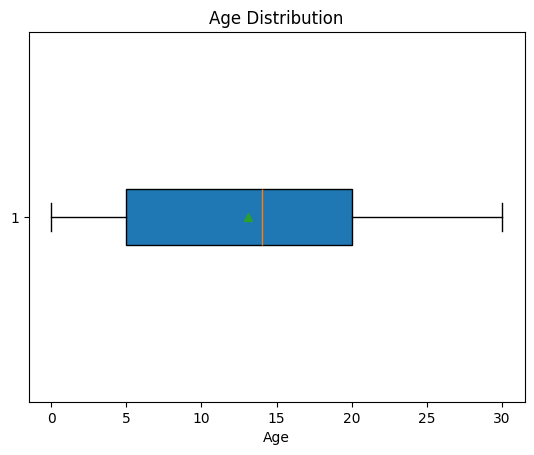

In [98]:
plt.boxplot(df['age'], vert=False, patch_artist=True, showmeans=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

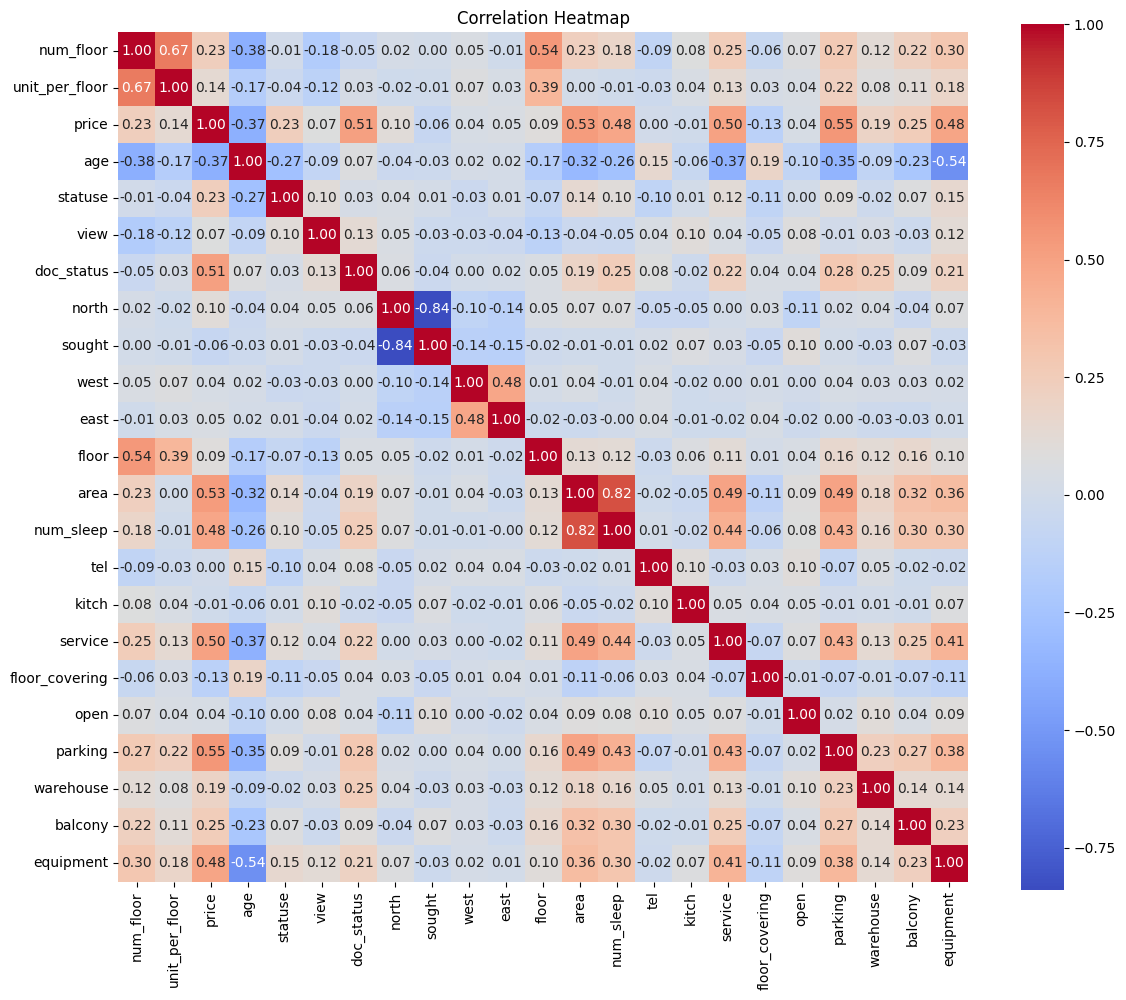

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns and compute correlation matrix
numerical_df = df.select_dtypes(include=['number'])
corr_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title("Correlation Heatmap")

# Save the plot to a file
plt.tight_layout()
plt.savefig('plot/correlation_heatmap.png', dpi=300, bbox_inches='tight')

# Display the plot (optional)
plt.show()

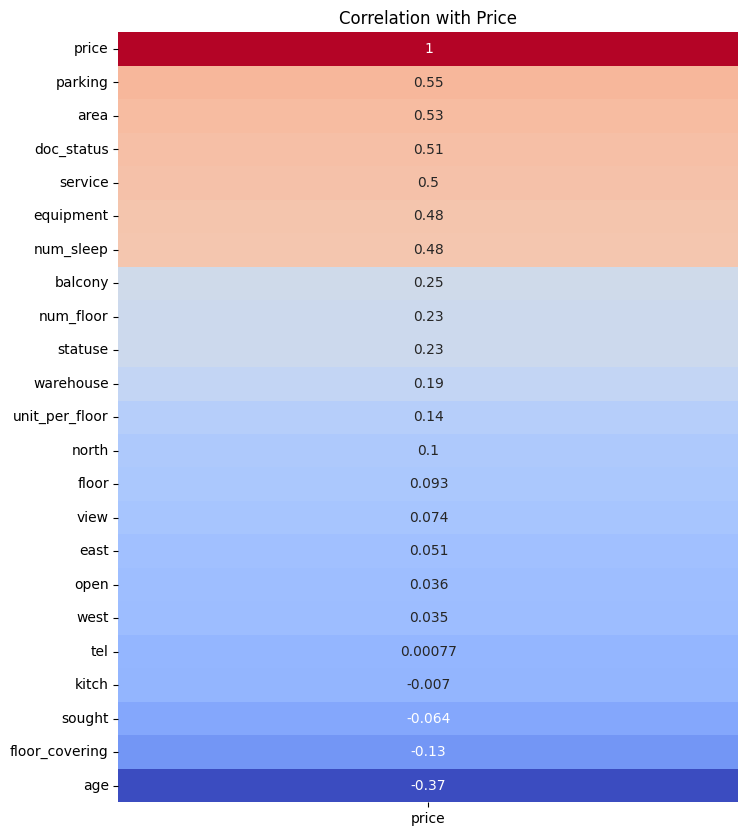

In [100]:
price_corr = numerical_df.corr()['price'].sort_values(ascending=False)
plt.figure(figsize=(8, 10))
sns.heatmap(price_corr.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title("Correlation with Price")
plt.show()

Text(0.5, 1.0, 'Count of Each Address')

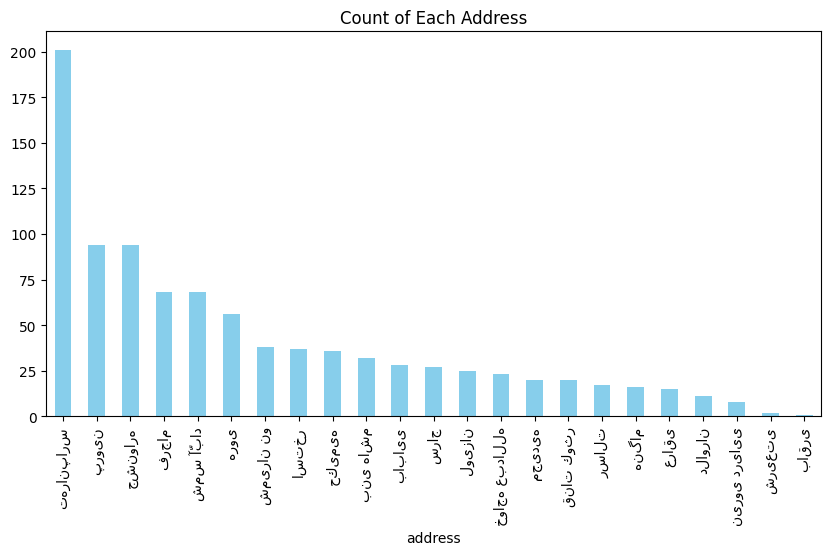

In [101]:
df['address'].value_counts().plot.bar(figsize=(10, 5), color='skyblue')
plt.title('Count of Each Address')

In [102]:
dict(df['address'].value_counts())

{'تهرانپارس': np.int64(201),
 'پروین': np.int64(94),
 'جشنواره': np.int64(94),
 'فرجام': np.int64(68),
 'شمس آّباد': np.int64(68),
 'هروی': np.int64(56),
 'شمیران نو': np.int64(38),
 'استخر': np.int64(37),
 'حكیمیه': np.int64(36),
 'بنی هاشم': np.int64(32),
 'بابایی': np.int64(28),
 'سراج': np.int64(27),
 'لویزان': np.int64(25),
 'خواجه عبدالله': np.int64(23),
 'مجیدیه': np.int64(20),
 'قنات كوثر': np.int64(20),
 'رسالت': np.int64(17),
 'هنگام': np.int64(16),
 'عراقی': np.int64(15),
 'دلاوران': np.int64(11),
 'نیروی دریایی': np.int64(8),
 'شریعتی': np.int64(2),
 'باقری': np.int64(1)}

In [103]:
threshold = 10
df['address'] = df['address'].apply(lambda x: x if dict(df['address'].value_counts()).get(x, 0) > threshold else 'Other')

In [104]:
dict(df['address'].value_counts())

{'تهرانپارس': np.int64(201),
 'پروین': np.int64(94),
 'جشنواره': np.int64(94),
 'شمس آّباد': np.int64(68),
 'فرجام': np.int64(68),
 'هروی': np.int64(56),
 'شمیران نو': np.int64(38),
 'استخر': np.int64(37),
 'حكیمیه': np.int64(36),
 'بنی هاشم': np.int64(32),
 'بابایی': np.int64(28),
 'سراج': np.int64(27),
 'لویزان': np.int64(25),
 'خواجه عبدالله': np.int64(23),
 'قنات كوثر': np.int64(20),
 'مجیدیه': np.int64(20),
 'رسالت': np.int64(17),
 'هنگام': np.int64(16),
 'عراقی': np.int64(15),
 'Other': np.int64(11),
 'دلاوران': np.int64(11)}

In [105]:
#target encoding
address_mean_price = df.groupby('address')['price'].transform('mean')
df['address_encoded'] = address_mean_price

In [106]:
address_mean_price

0      1.050914e+08
1      7.845457e+07
2      1.050620e+08
3      1.332114e+08
4      9.314929e+07
           ...     
932    1.050620e+08
933    1.009411e+08
934    7.845457e+07
935    7.845457e+07
936    7.096471e+07
Name: price, Length: 937, dtype: float64

In [107]:
average_price_per_address = df.groupby('address')['price'].mean().sort_values(ascending=False)
dict(average_price_per_address)

{'عراقی': np.float64(136000000.0),
 'هروی': np.float64(133211394.75856705),
 'خواجه عبدالله': np.float64(129920574.94383696),
 'شمس آّباد': np.float64(117123287.98185809),
 'بنی هاشم': np.float64(110209030.55614653),
 'لویزان': np.float64(107240798.04078884),
 'تهرانپارس': np.float64(105091421.34582506),
 'فرجام': np.float64(105061985.28681415),
 'قنات كوثر': np.float64(101752350.49036562),
 'مجیدیه': np.float64(100941068.47644193),
 'بابایی': np.float64(99223079.5689065),
 'Other': np.float64(94510235.2879677),
 'هنگام': np.float64(93149289.77785148),
 'رسالت': np.float64(93058213.00587389),
 'استخر': np.float64(91699562.22860102),
 'سراج': np.float64(82872063.33125547),
 'حكیمیه': np.float64(82336804.55314907),
 'پروین': np.float64(78454572.53625768),
 'دلاوران': np.float64(74209451.6038544),
 'جشنواره': np.float64(70964705.45363231),
 'شمیران نو': np.float64(43877788.9522188)}

In [108]:
average_price_per_address = df.groupby('address')['price'].median().sort_values(ascending=False)
dict(average_price_per_address)

{'خواجه عبدالله': np.float64(140000000.0),
 'عراقی': np.float64(140000000.0),
 'هروی': np.float64(140000000.0),
 'شمس آّباد': np.float64(119917355.37190083),
 'بنی هاشم': np.float64(110113636.36363637),
 'لویزان': np.float64(110000000.0),
 'فرجام': np.float64(102368372.26548016),
 'تهرانپارس': np.float64(101515151.51515152),
 'بابایی': np.float64(98333333.33333334),
 'قنات كوثر': np.float64(95000000.0),
 'مجیدیه': np.float64(93012871.02705543),
 'Other': np.float64(91666666.66666667),
 'رسالت': np.float64(90277777.77777778),
 'هنگام': np.float64(90045045.04504505),
 'استخر': np.float64(90000000.0),
 'سراج': np.float64(86419753.08641975),
 'حكیمیه': np.float64(77925531.91489363),
 'پروین': np.float64(74582289.05597326),
 'دلاوران': np.float64(72115384.61538461),
 'جشنواره': np.float64(70000000.0),
 'شمیران نو': np.float64(45454545.45454545)}

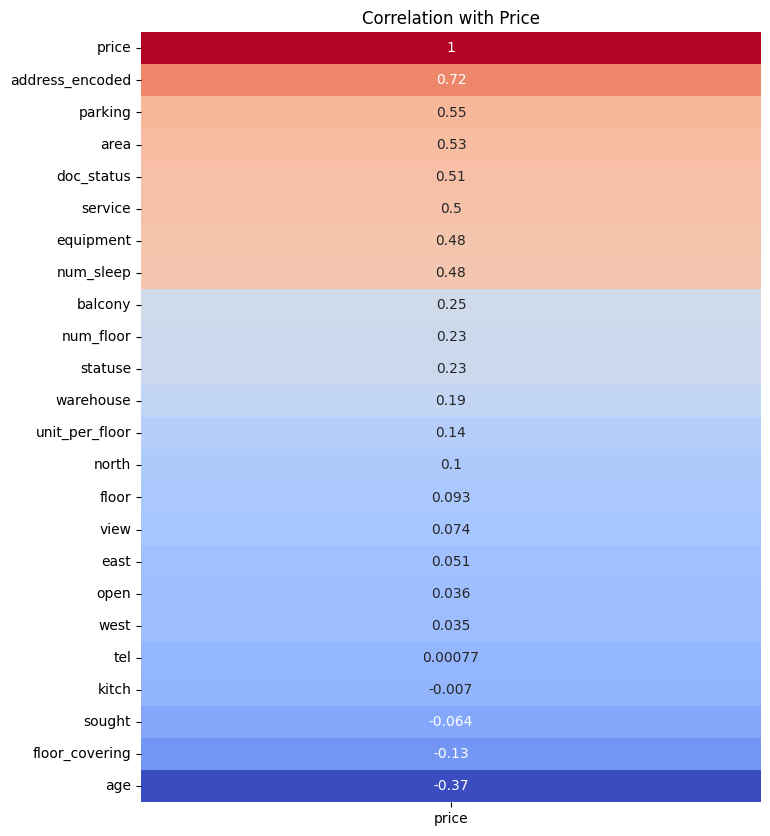

In [109]:
numerical_df = df.select_dtypes(include=['number'])
price_corr = numerical_df.corr()['price'].sort_values(ascending=False)
plt.figure(figsize=(8, 10))
sns.heatmap(price_corr.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title("Correlation with Price")
plt.show()

In [110]:
df = df.drop(['address'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   num_floor        937 non-null    int64  
 1   unit_per_floor   937 non-null    float64
 2   price            937 non-null    float64
 3   age              937 non-null    int64  
 4   statuse          937 non-null    int64  
 5   view             937 non-null    int64  
 6   doc_status       937 non-null    int64  
 7   north            937 non-null    int64  
 8   sought           937 non-null    int64  
 9   west             937 non-null    int64  
 10  east             937 non-null    float64
 11  floor            937 non-null    int64  
 12  area             937 non-null    int64  
 13  num_sleep        937 non-null    float64
 14  tel              929 non-null    float64
 15  kitch            937 non-null    int64  
 16  service          937 non-null    int64  
 17  floor_covering  

In [111]:
df['room_to_area'] = df['num_sleep'] / df['area']

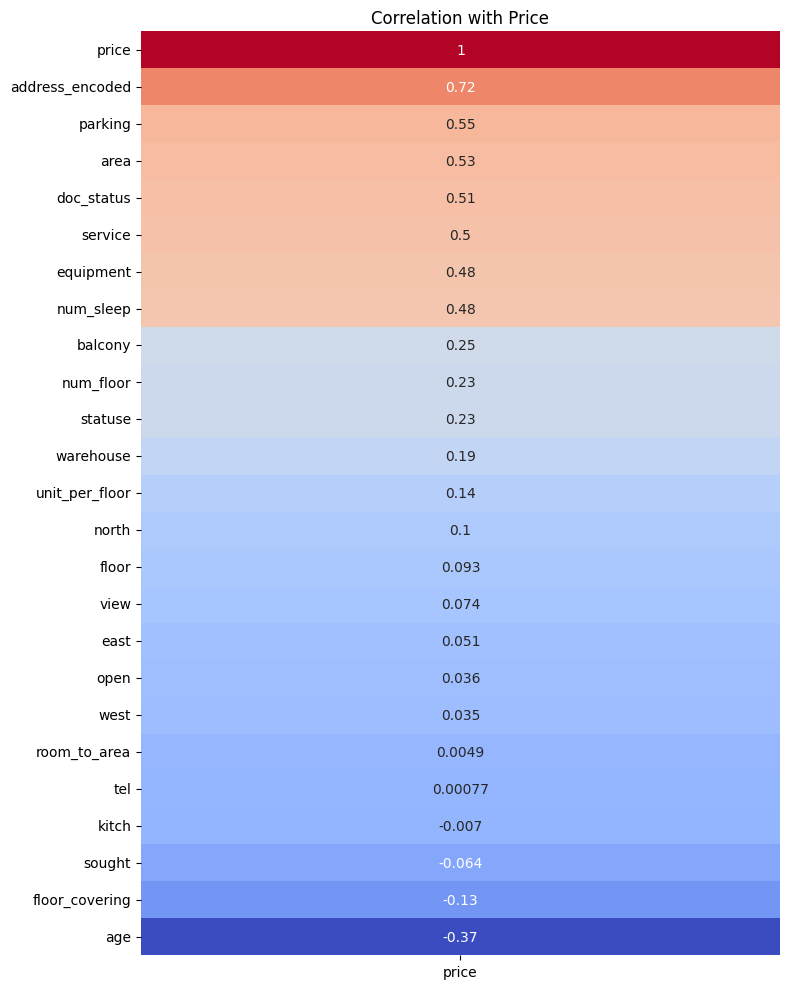

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns and calculate correlations with 'price'
numerical_df = df.select_dtypes(include=['number'])
price_corr = numerical_df.corr()['price'].sort_values(ascending=False)

# Plot the correlation heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(price_corr.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title("Correlation with Price")

# Save the plot
plt.tight_layout()
plt.savefig('plot/correlation_with_price.png', dpi=300, bbox_inches='tight')

# Show the plot (optional)
plt.show()

In [113]:
df.to_csv('HomeDataset_after_preprocess.csv', index=False, encoding='utf-8-sig')